---
title: EDA on Visa Dataset (Project)
description: A simple EDA project on the Visa dataset using Python and its libraries.
author: Md Muztahid Hassan
date: '2026-05-14 21:15:00'
toc: true
execute:
  warning: false
  echo: true
order: 9
---


## Loading the libraries and the dataset

At first, we need to import the necessary libraries.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Now we will load the dataset. You can download the dataset from <a href="Visadataset.csv">here</a>.



In [2]:
df = pd.read_csv('Visadataset.csv')
df.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


In [3]:
df.shape

(25480, 12)

## Summary of the dataset

In [4]:
df.describe()

,no_of_employees,yr_of_estab,prevailing_wage
count,25480.000000,25480.000000,25480.000000
mean,5667.043210,1979.409929,74455.814592
std,22877.928848,42.366929,52815.942327
min,-26.000000,1800.000000,2.136700
25%,1022.000000,1976.000000,34015.480000
50%,2109.000000,1997.000000,70308.210000
75%,3504.000000,2005.000000,107735.512500
max,602069.000000,2016.000000,319210.270000


The `describe()` method only shows the numerical columns. 

## Checking Null values and Data types

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB


In [6]:
df.isnull().sum()

case_id                  0
continent                0
education_of_employee    0
has_job_experience       0
requires_job_training    0
no_of_employees          0
yr_of_estab              0
region_of_employment     0
prevailing_wage          0
unit_of_wage             0
full_time_position       0
case_status              0
dtype: int64

## Exploring the data

For exploring the data, we need to separate the numerical and categorical columns.

In [7]:
# Create new DataFrames based on data types
numerical_features = df.select_dtypes(exclude=['object'])
categorical_features = df.select_dtypes(include=['object'])

# Print the results
print(f'We have {len(numerical_features.columns)} numerical features : {numerical_features.columns.tolist()}')
print(f'\nWe have {len(categorical_features.columns)} categorical features : {categorical_features.columns.tolist()}')

We have 3 numerical features : ['no_of_employees', 'yr_of_estab', 'prevailing_wage']

We have 9 categorical features : ['case_id', 'continent', 'education_of_employee', 'has_job_experience', 'requires_job_training', 'region_of_employment', 'unit_of_wage', 'full_time_position', 'case_status']


If we want to know the counts of the unique values in a categorical column, we can use the `value_counts()` method.

In [8]:
df['continent'].value_counts()

continent
Asia             16861
Europe            3732
North America     3292
South America      852
Africa             551
Oceania            192
Name: count, dtype: int64

If we want to see the result as percentage, we can set the `normalize` parameter to `True`. We can do this for all the categorical columns. 

In [9]:
from IPython.display import display

for col in categorical_features:
    print(f"\n🔹 Feature: {col.upper()}")
    
    # Calculate, round to 2 decimal places, and convert to a DataFrame
    summary_df = (df[col].value_counts(normalize=True) * 100).round(2).to_frame(name='Percentage (%)')
    summary_df.index.name = 'Category'
    
    # Render the formatted table
    display(summary_df)


🔹 Feature: CASE_ID


,Percentage (%)
Category,
EZYV01,0.0
EZYV02,0.0
EZYV03,0.0
EZYV04,0.0
EZYV05,0.0
...,...
EZYV25476,0.0
EZYV25477,0.0
EZYV25478,0.0



🔹 Feature: CONTINENT


,Percentage (%)
Category,
Asia,66.17
Europe,14.65
North America,12.92
South America,3.34
Africa,2.16
Oceania,0.75



🔹 Feature: EDUCATION_OF_EMPLOYEE


...

,Percentage (%)
Category,
Year,90.12
Hour,8.47
Week,1.07
Month,0.35



🔹 Feature: FULL_TIME_POSITION


,Percentage (%)
Category,
Y,89.38
N,10.62



🔹 Feature: CASE_STATUS


,Percentage (%)
Category,
Certified,66.79
Denied,33.21


> We can use ydata-profiling to automate this process. 

**Insights**
 - `case_id` have unique vlaues for each column which can be dropped as it it of no importance
 - `continent` column is highly biased towards asia. hence we can combine other categories to form a single category.
 - `unit_of_wage` seems to be an important column as most of them are yearly contracts.


## Univariate Analysis
We will do univariate analysis on the numerical columns and categorical features separately.
### Numerical Features

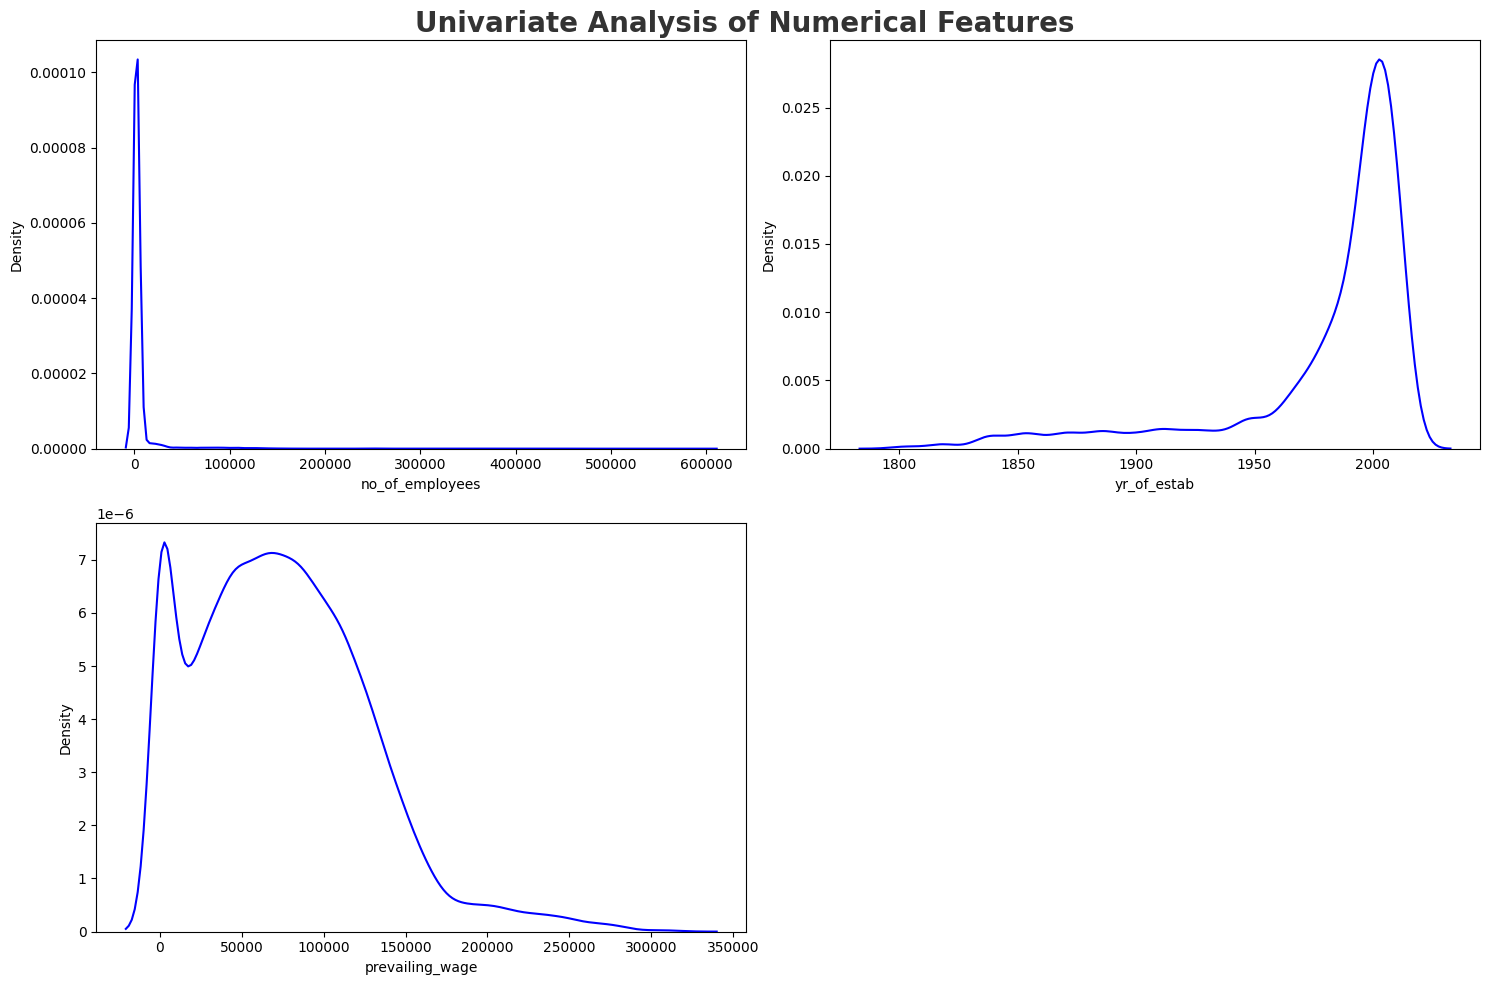

In [10]:
import math

num_cols = numerical_features.columns
total_plots = len(num_cols)
num_rows = math.ceil(total_plots / 2)
fig, ax= plt.subplots(num_rows, 2, figsize=(15, 5*num_rows))
fig.suptitle('Univariate Analysis of Numerical Features', fontsize=20, fontweight='bold', alpha=0.8)

axes = ax.flatten() if total_plots > 1 else [ax]
for i in range(len(num_cols)):
    sns.kdeplot(data=df, x=num_cols[i], color='blue', ax=axes[i])
    axes[i].set_xlabel(num_cols[i])

for j in range(total_plots, len(axes)):
    fig.delaxes(axes[j])

fig.tight_layout()
fig.subplots_adjust(top=0.95)
plt.show()

**Feature-by-Feature Insights**

* **`no_of_employees`**: Highly right-skewed; most are very small companies, but a few massive corporate outliers stretch the tail past 600,000.
* **`yr_of_estab`**: Left-skewed; most companies are relatively modern (established 1990–2010), with a long tail of much older businesses.
* **`prevailing_wage`**: Bimodal distribution with two distinct peaks representing hourly wages (near $0) and standard yearly salaries ($50k–$100k).

### Categorical Features

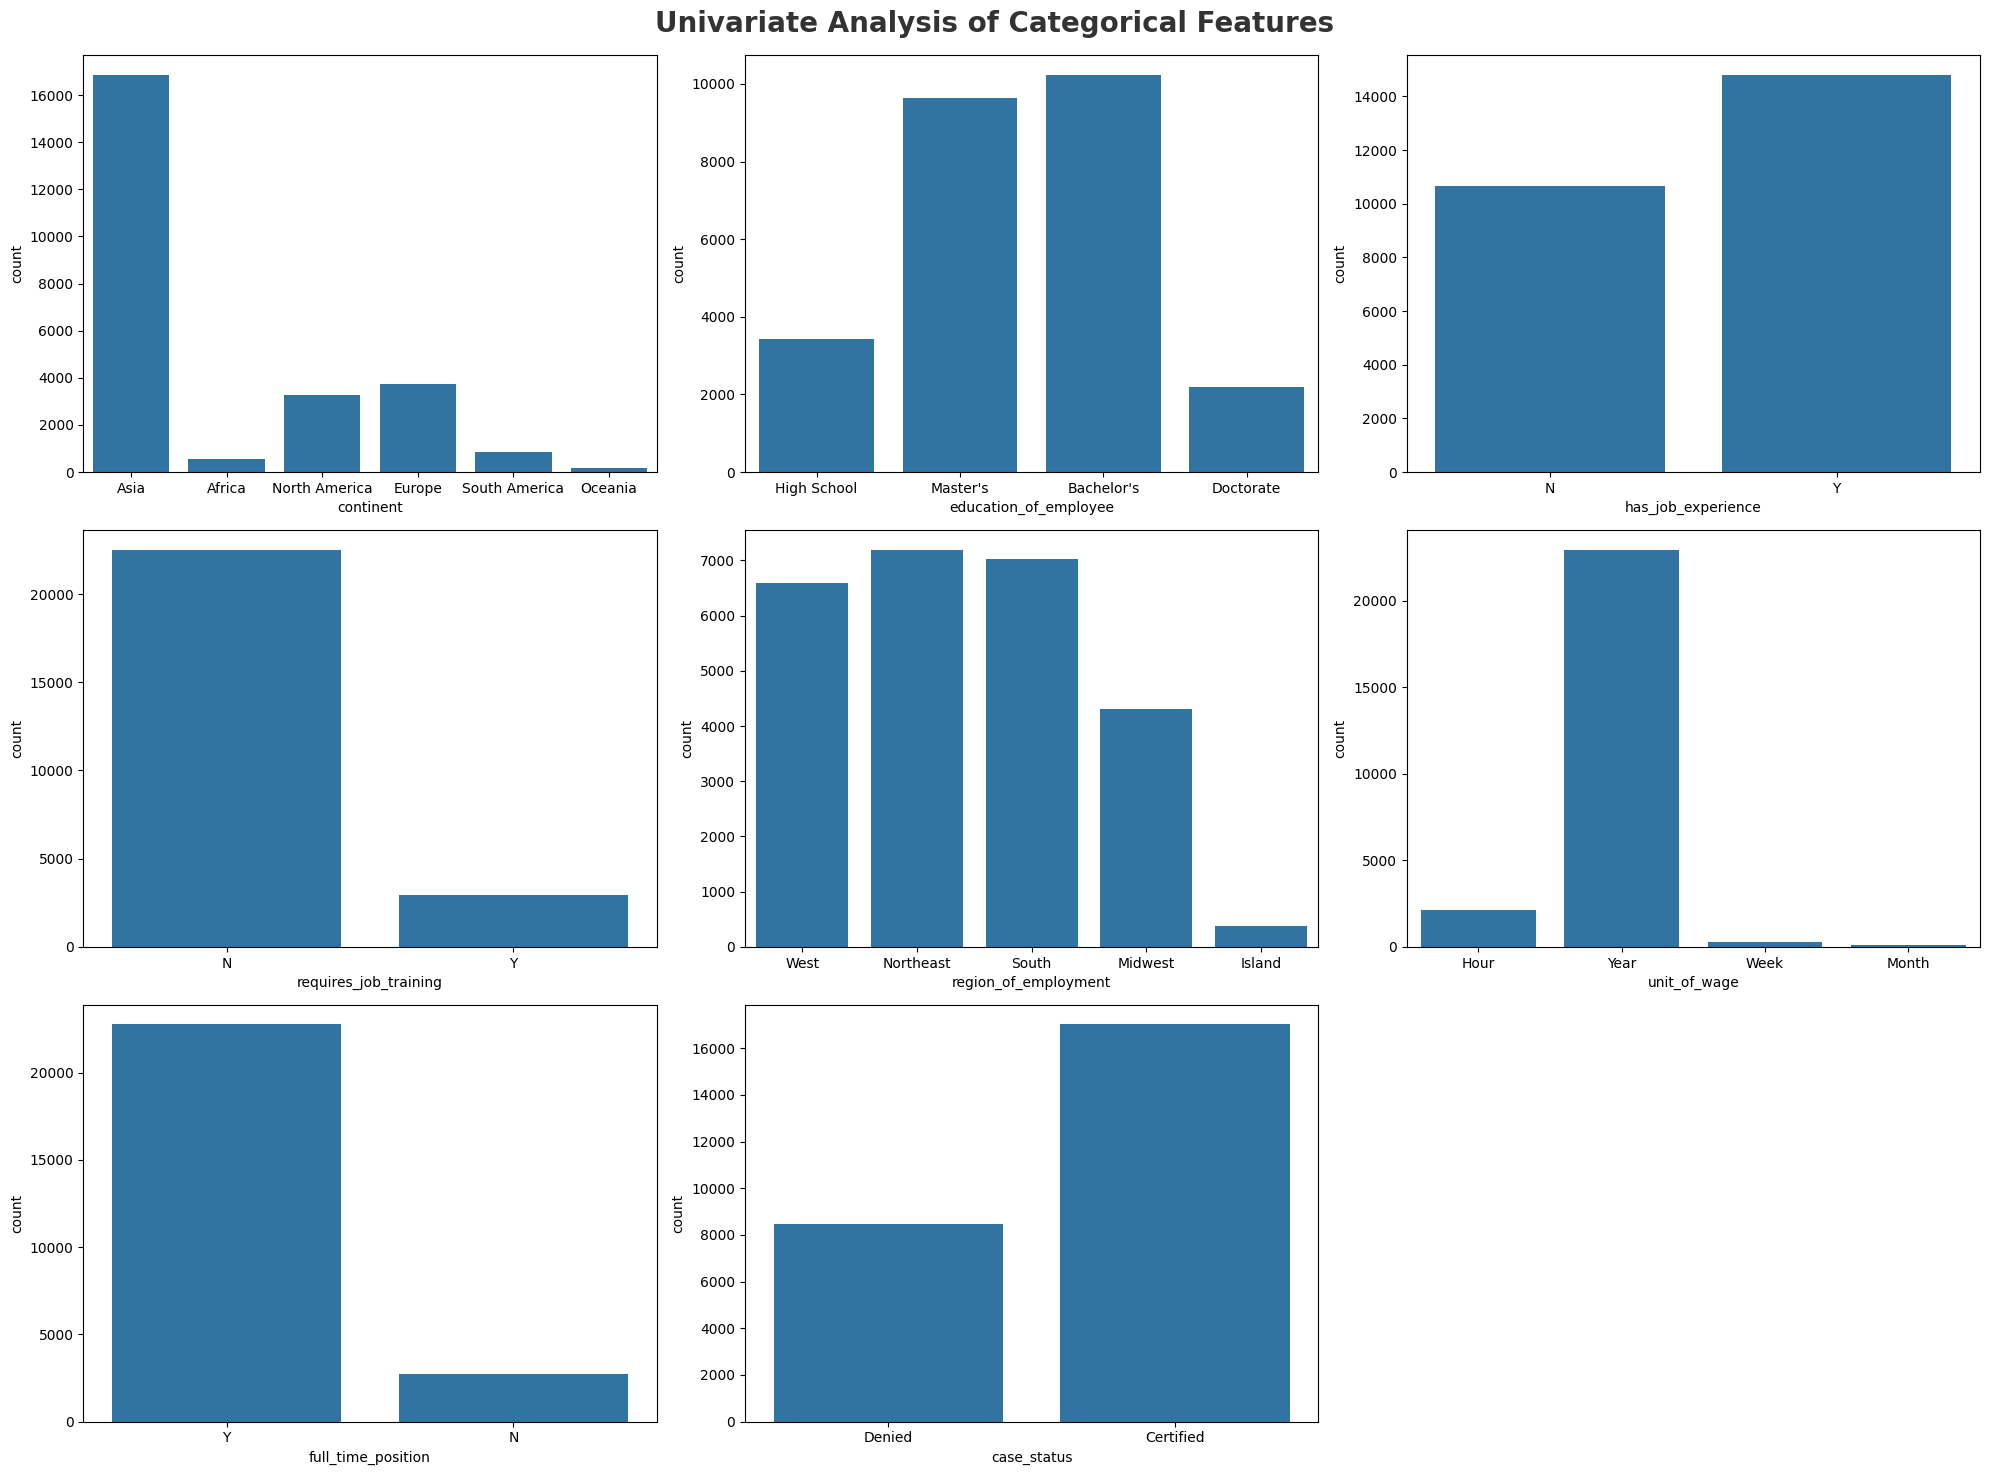

In [11]:
categorical_features=categorical_features.drop(columns=['case_id'])

cat_cols = categorical_features.columns
total_plots = len(cat_cols)
num_rows = math.ceil(total_plots / 3)
fig, ax = plt.subplots(num_rows, 3, figsize=(20, 5*num_rows))
fig.suptitle('Univariate Analysis of Categorical Features', fontsize=20, fontweight='bold', alpha=0.8)

axes = ax.flatten() if total_plots > 1 else [ax]

for i in range(len(cat_cols)):
    sns.countplot(data=df, x=cat_cols[i], ax=axes[i])
    axes[i].set_xlabel(cat_cols[i])

for j in range(total_plots, len(axes)):
    fig.delaxes(axes[j])

fig.tight_layout()
fig.subplots_adjust(top=0.95)
plt.show()

**Feature-by-Feature Insights**

* **`continent`**: Applicants are overwhelmingly from Asia (16,000+), with Europe and North America trailing far behind.
* **`education_of_employee`**: The majority hold a Bachelor's or Master's degree, split almost evenly at roughly 10,000 each.
* **`has_job_experience`**: Applicants with job experience (Y) outnumber those without (N) by a moderate margin.
* **`requires_job_training`**: Almost all positions (22,000+) do not require additional job training (N).
* **`region_of_employment`**: Jobs are fairly evenly distributed across the West, Northeast, and South, with very few in the Islands.
* **`unit_of_wage`**: The vast majority of salaries are calculated on a Yearly basis, making this feature highly imbalanced.
* **`full_time_position`**: Nearly all applications are for full-time positions (Y), with very few part-time roles represented.
* **`case_status`**: The approval rate is roughly 2-to-1, with about 17,000 cases Certified and 8,500 Denied.

## Multivariate Analysis

At first, we will separate the discrete and continuous features from numerical features. 

In [12]:
discrete_features = [col for col in numerical_features.columns if numerical_features[col].nunique() <= 25]
continuous_features = [col for col in numerical_features.columns if numerical_features[col].nunique() > 25]

discrete_features=numerical_features[discrete_features]
continuous_features=numerical_features[continuous_features]

print(f'We have {len(discrete_features.columns)} discrete features : {list(discrete_features.columns)}')
print(f'\nWe have {len(continuous_features.columns)} continuous features : {list(continuous_features.columns)}')

We have 0 discrete features : []

We have 3 continuous features : ['no_of_employees', 'yr_of_estab', 'prevailing_wage']


### Checking Multicollinearity
If we want to check the correlation between the numerical features, we can use the `corr()` method. 

In [13]:
df.corr(numeric_only=True)

,no_of_employees,yr_of_estab,prevailing_wage
no_of_employees,1.000000,-0.017770,-0.009523
yr_of_estab,-0.017770,1.000000,0.012342
prevailing_wage,-0.009523,0.012342,1.000000


But what about the categorical features? We will use the `Chi-Square test` to check the correlation between the categorical features. 
In statistics, the **Null Hypothesis** assumes that the two columns have no relationship at all. We assume the `alpha`(Significance level) to be 0.05. Here `alpha` is the threshold we set for rejecting the null hypothesis. 
`P-value` is the result of the chi-square test. If the `p-value` is less than `alpha`, we reject the null hypothesis and conclude that there is a significant association between the feature and the target variable. Otherwise, we fail to reject the null hypothesis, suggesting no significant association between the feature and the target variable. In that case, we may consider dropping the feature from our model.

In [14]:
from scipy.stats import chi2_contingency

chi2_results = []

for feature in cat_cols:
    crosstab = pd.crosstab(df['case_status'], df[feature])
    chi2, p_value, dof, expected = chi2_contingency(crosstab)
    if p_value < 0.05: # Checking significance level (alpha = 0.05)
        decision = 'Reject Null (Significant Relationship)'
    else:
        decision = 'Fail to Reject (No Relationship)'
        
    chi2_results.append({
        'Feature': feature,
        'P-Value': p_value, 
        'Hypothesis Result': decision
    })

result = pd.DataFrame(chi2_results)
result

,Feature,P-Value,Hypothesis Result
0,continent,8.828798e-74,Reject Null (Significant Relationship)
1,education_of_employee,0.000000e+00,Reject Null (Significant Relationship)
2,has_job_experience,1.922560e-206,Reject Null (Significant Relationship)
3,requires_job_training,1.855647e-01,Fail to Reject (No Relationship)
4,region_of_employment,2.338664e-63,Reject Null (Significant Relationship)
5,unit_of_wage,5.193385e-240,Reject Null (Significant Relationship)
6,full_time_position,4.469975e-02,Reject Null (Significant Relationship)
7,case_status,0.000000e+00,Reject Null (Significant Relationship)


**Insights**:
Here we can see that the 'requires_job_training' feature has a p-value of 0.18, which is greater than our alpha threshold of 0.05. So there is no relationship between the 'requires_job_training' feature and the target variable 'case_status'. Hence we can drop this feature from our model.

### Checking Null values

In [15]:
df.isnull().sum()

case_id                  0
continent                0
education_of_employee    0
has_job_experience       0
requires_job_training    0
no_of_employees          0
yr_of_estab              0
region_of_employment     0
prevailing_wage          0
unit_of_wage             0
full_time_position       0
case_status              0
dtype: int64

### Working with coninuous features

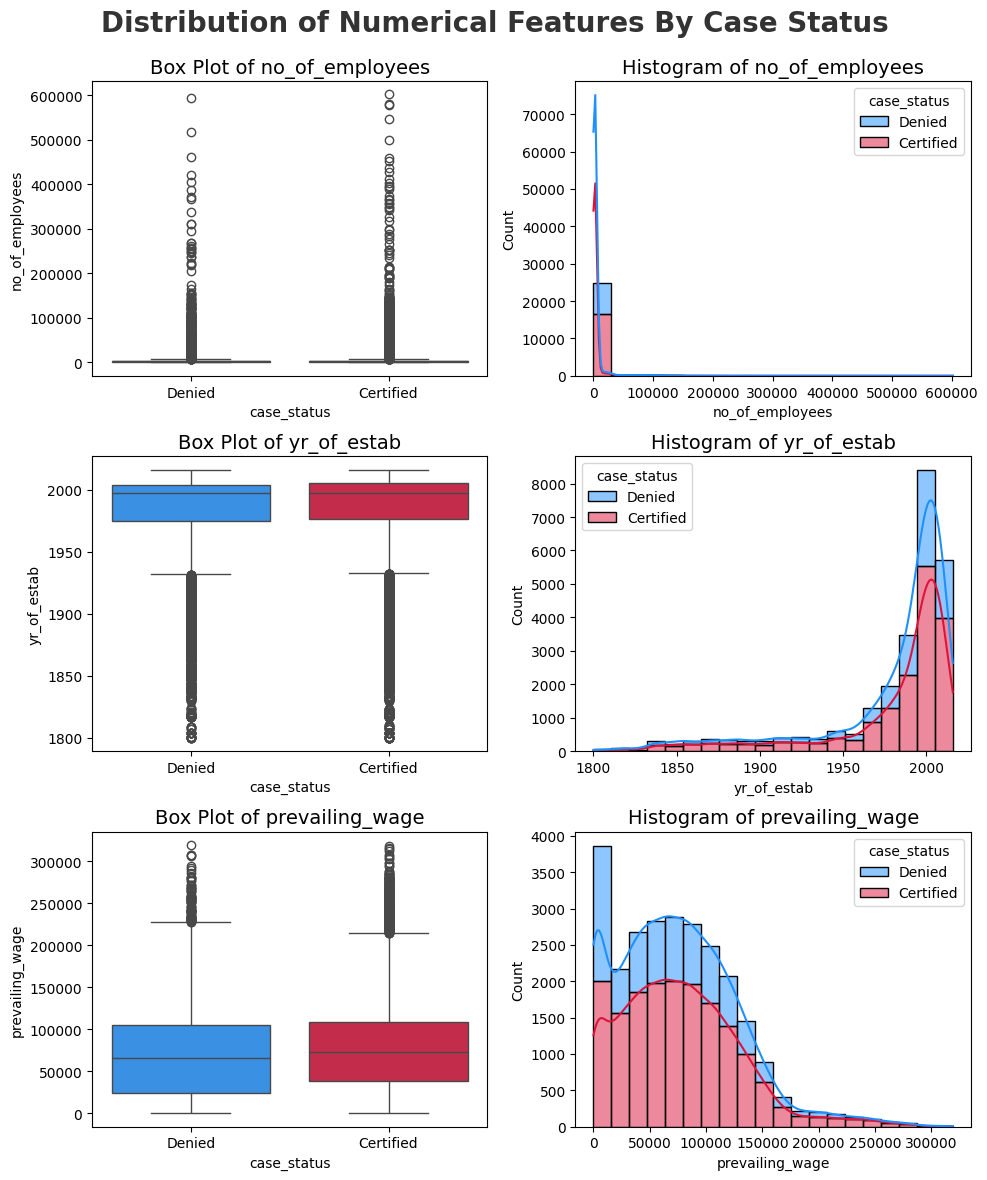

In [16]:
cont_cols = continuous_features.columns
num_rows = len(cont_cols)
clr1 = ['#1E90FF', '#DC143C']
fig, ax = plt.subplots(num_rows, 2, figsize=(10, num_rows*4))
fig.suptitle('Distribution of Numerical Features By Case Status', fontsize=20, fontweight='bold', alpha=0.8)

for i, col in enumerate(cont_cols):
    sns.boxplot(data=df, x='case_status', y=col, hue='case_status', palette=clr1, ax=ax[i, 0])
    ax[i, 0].set_title(f'Box Plot of {col}', fontsize=14)

    sns.histplot(data=df, x=col, hue='case_status', bins=20, multiple='stack', palette=clr1, ax=ax[i, 1], kde=True, legend=True)
    ax[i,1].set_title(f'Histogram of {col}', fontsize=14)

fig.tight_layout()
fig.subplots_adjust(top=0.92)
plt.show()

### Initial Analysis Report

* **No of Employees has many outliers which can be Handled in Feature Engineering and `no_of_employees` is Right Skewed.**
* **`yr_of_estab` is left skewed and some outliers below the lower bound of Box plot.**
* **`prevailing_wage` is right skewed with outliers above upper bound of box plot.**
* **There are No missing values in the dataset.**
* **The `case_id` column can be deleted because each row has unique values.**
* **The `case_status` column is the target to predict.**
* **In the Categorical column, features can be made Binary numerical in feature Encoding**

## Visualizing the target variable

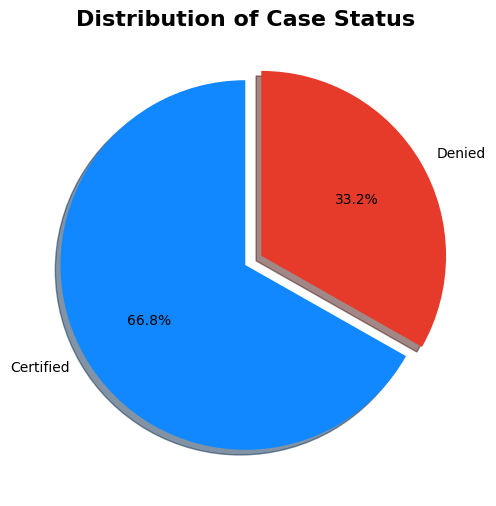

In [17]:
percentage = df['case_status'].value_counts(normalize=True) * 100
labels = percentage.index

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#1188ff', '#e63a2a']
explode = (0, 0.1)
ax.pie(percentage, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors, explode=explode, shadow=True)
ax.set_title('Distribution of Case Status', fontsize=16, fontweight='bold')
plt.show()

From the chart it is seen that the Target Variable is Imbalanced
**What is imbalanced data?**

Imbalanced data occurs when the target class has an uneven distribution of observations. In this dataset, there is a moderate imbalance, as the Certified cases (66.8%) have a significantly higher count than the Denied cases (33.2%).

Now we will try to answer some questions based on the dataset.
## Does applicant Continent has any impact on Visa status ?

In [18]:
(df.groupby('continent')['case_status'].value_counts(normalize=True).to_frame(name='percentage(%)')*100).round(2)

percentage(%)
continent     case_status               
Africa        Certified            72.05
              Denied               27.95
Asia          Certified            65.31
              Denied               34.69
Europe        Certified            79.23
              Denied               20.77
North America Certified            61.88
              Denied               38.12
Oceania       Certified            63.54
              Denied               36.46
South America Certified            57.86
              Denied               42.14

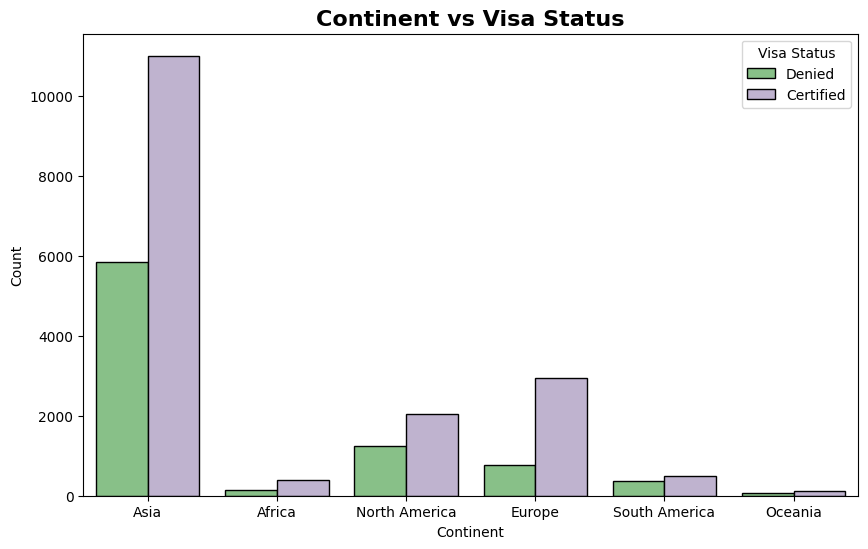

In [19]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='continent', hue='case_status', palette='Accent', edgecolor='black')
plt.title('Continent vs Visa Status', fontsize=16, fontweight='bold')
plt.xlabel('Continent')
plt.ylabel('Count')
plt.legend(title='Visa Status', fancybox=True)
plt.show()

If we want to see only the `certified` cases by continent, we can do the following process.

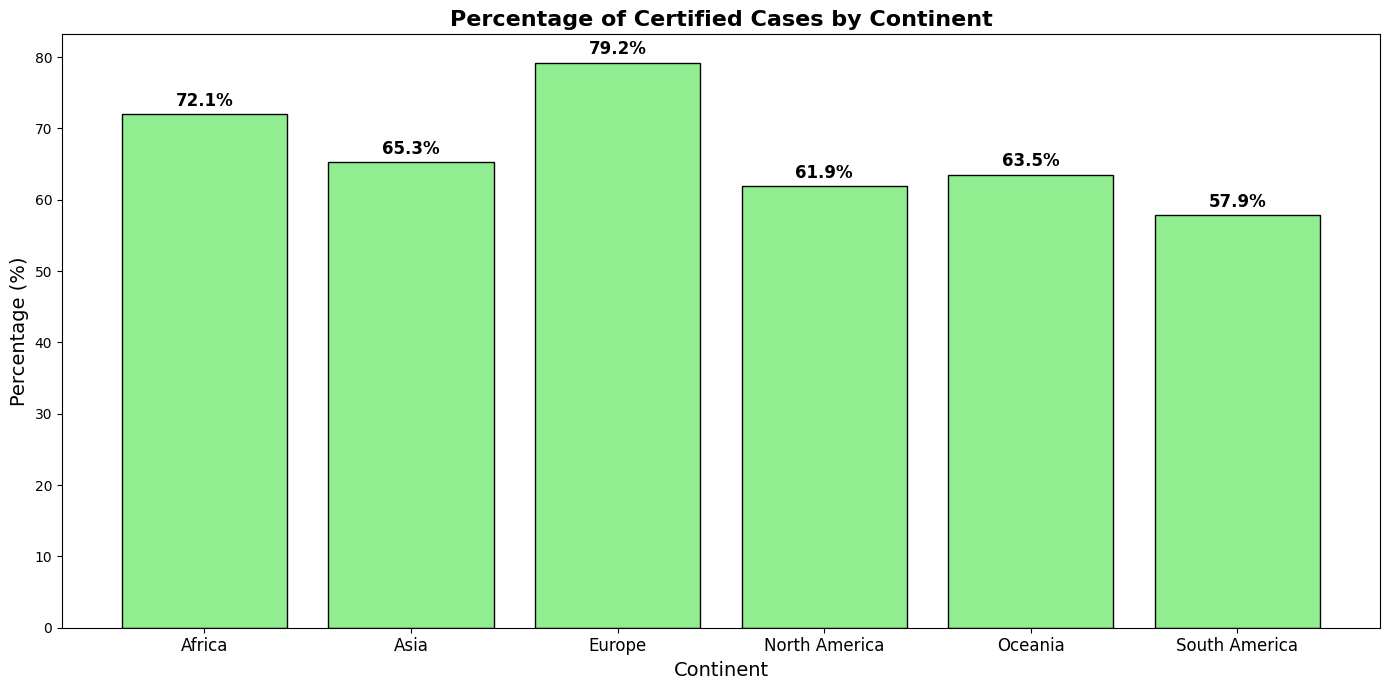

In [20]:
pct_df = pd.crosstab(df['continent'], df['case_status'], normalize='index') * 100
cert_pct = pct_df['Certified']
fig, ax = plt.subplots(figsize=(14, 7))

bars = ax.bar(cert_pct.index, cert_pct.values, color='lightgreen', edgecolor='black')
ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=12, fontweight='bold')

ax.set_title("Percentage of Certified Cases by Continent", fontsize=16, fontweight='bold')
ax.set_xlabel('Continent', fontsize=14)
ax.set_ylabel('Percentage (%)', fontsize=14)
ax.tick_params(axis='x', rotation=0, labelsize=12)
fig.tight_layout()
plt.show()

**Insights:**
* As per the Chart Asia applicants applied more than other continents.
* 43% of Certified applications are from Asia.
* This is followed by Europe with 11% of Certified applications.
* Highest chance of getting certified if you are from `Europe` and followed by `Africa`

## Does the education of applicant has any impact on Visa status ?

In [21]:
(df.groupby('education_of_employee')['case_status'].value_counts(normalize=True).to_frame(name='percentage(%)')*100).round(2)

percentage(%)
education_of_employee case_status               
Bachelor's            Certified            62.21
                      Denied               37.79
Doctorate             Certified            87.23
                      Denied               12.77
High School           Denied               65.96
                      Certified            34.04
Master's              Certified            78.63
                      Denied               21.37

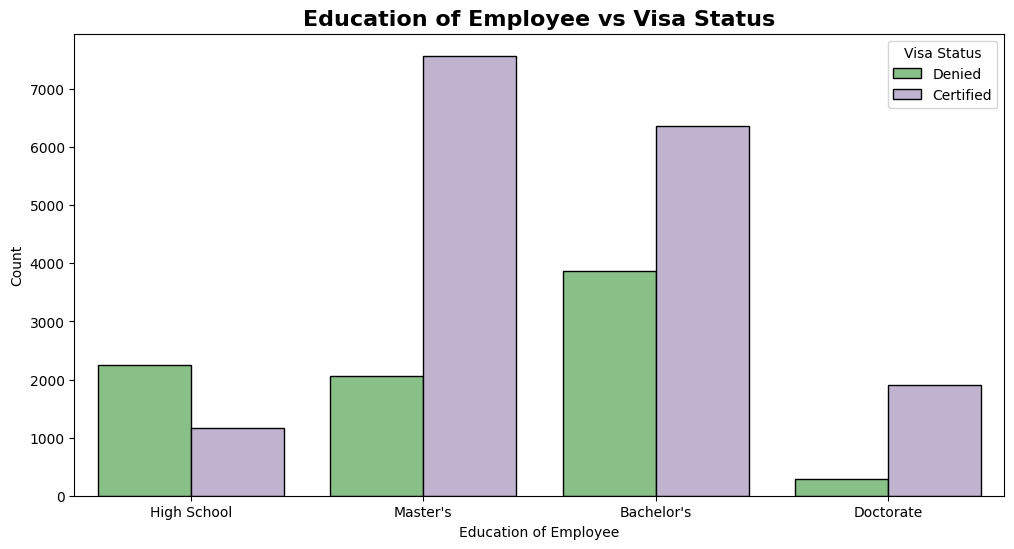

In [22]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='education_of_employee', hue='case_status', palette='Accent', edgecolor='black')
plt.title('Education of Employee vs Visa Status', fontsize=16, fontweight='bold')
plt.xlabel('Education of Employee')
plt.ylabel('Count')
plt.legend(title='Visa Status', fancybox=True)
plt.show()

If we want to see only the `certified` cases by education, we can do the following process.

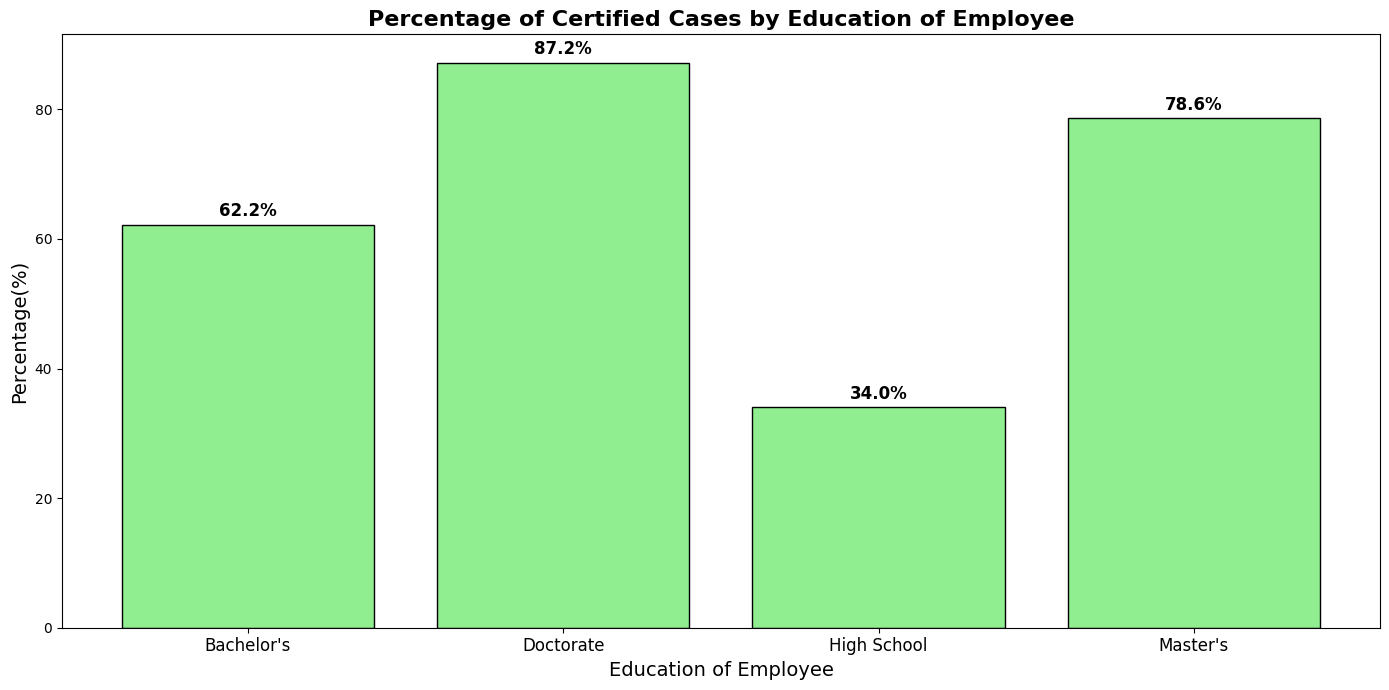

In [23]:
pct_df = pd.crosstab(df['education_of_employee'], df['case_status'], normalize='index') * 100
cert_pct = pct_df['Certified']
fig, ax = plt.subplots(figsize=(14, 7))

bars = ax.bar(cert_pct.index, cert_pct.values, color='lightgreen', edgecolor='black')
ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=12, fontweight='bold')

ax.set_title("Percentage of Certified Cases by Education of Employee", fontsize=16, fontweight='bold')
ax.set_xlabel('Education of Employee', fontsize=14)
ax.set_ylabel('Percentage(%)', fontsize=14)
ax.tick_params(axis='x', rotation=0, labelsize=12)
fig.tight_layout()
plt.show()

**Insights**
- education status has high impact
- `Doctorate` and `Master's` graduates have higher cange of being accepted then the others.

## Does applicant's previous work experience has any impact on Visa status ?

In [24]:
(df.groupby('has_job_experience')['case_status'].value_counts(normalize=True).to_frame(name='percentage(%)')*100).round(2)

percentage(%)
has_job_experience case_status               
N                  Certified            56.13
                   Denied               43.87
Y                  Certified            74.48
                   Denied               25.52

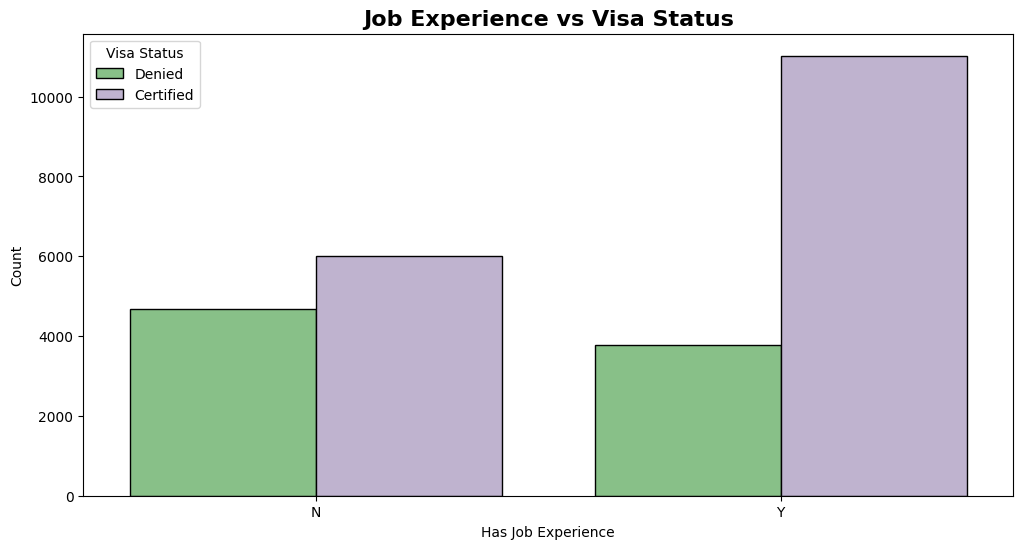

In [25]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='has_job_experience', hue='case_status', palette='Accent', edgecolor='black')
plt.title('Job Experience vs Visa Status', fontsize=16, fontweight='bold')
plt.xlabel('Has Job Experience')
plt.ylabel('Count')
plt.legend(title='Visa Status', fancybox=True)
plt.show()

If we want to see only the `certified` cases by job experience, we can do the following process.

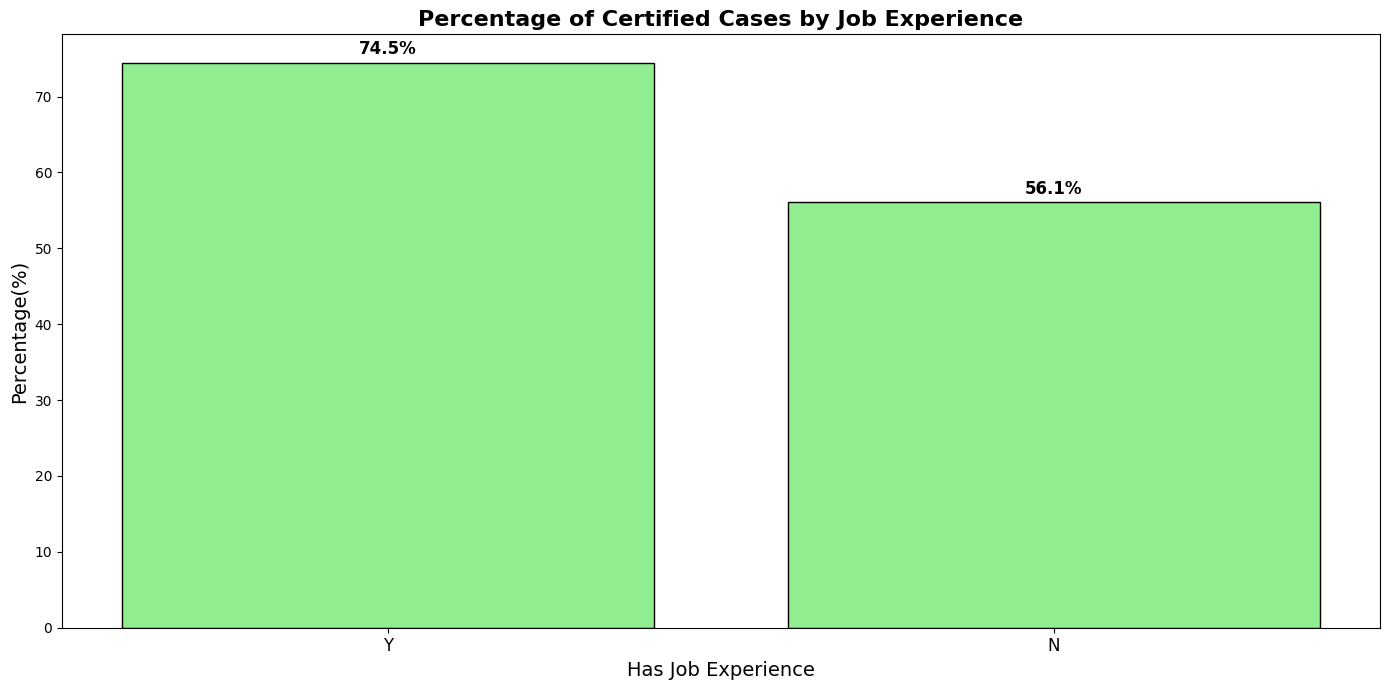

In [26]:
pct_df = pd.crosstab(df['has_job_experience'], df['case_status'], normalize='index') * 100
cert_pct = pct_df['Certified'].sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(14, 7))

bars = ax.bar(cert_pct.index, cert_pct.values, color='lightgreen', edgecolor='black')
ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=12, fontweight='bold')

ax.set_title("Percentage of Certified Cases by Job Experience", fontsize=16, fontweight='bold')
ax.set_xlabel('Has Job Experience', fontsize=14)
ax.set_ylabel('Percentage(%)', fontsize=14)
ax.tick_params(axis='x', rotation=0, labelsize=12)
fig.tight_layout()
plt.show()

## If the Employee requires job training, does it make any impact on visa status?

In [27]:
(df.groupby('requires_job_training')['case_status'].value_counts(normalize=True).to_frame(name='percentage(%)')*100).round(2)

percentage(%)
requires_job_training case_status               
N                     Certified            66.65
                      Denied               33.35
Y                     Certified            67.88
                      Denied               32.12

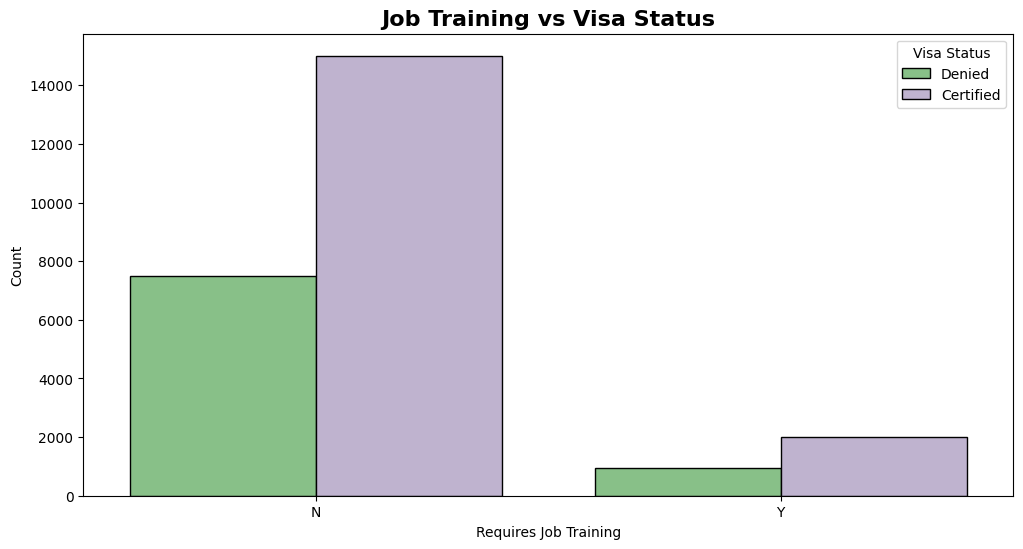

In [28]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='requires_job_training', hue='case_status', palette='Accent', edgecolor='black')
plt.title('Job Training vs Visa Status', fontsize=16, fontweight='bold')
plt.xlabel('Requires Job Training')
plt.ylabel('Count')
plt.legend(title='Visa Status', fancybox=True)
plt.show()

If we want to see only the `certified` cases by the requirement of job training, we can do the following process.

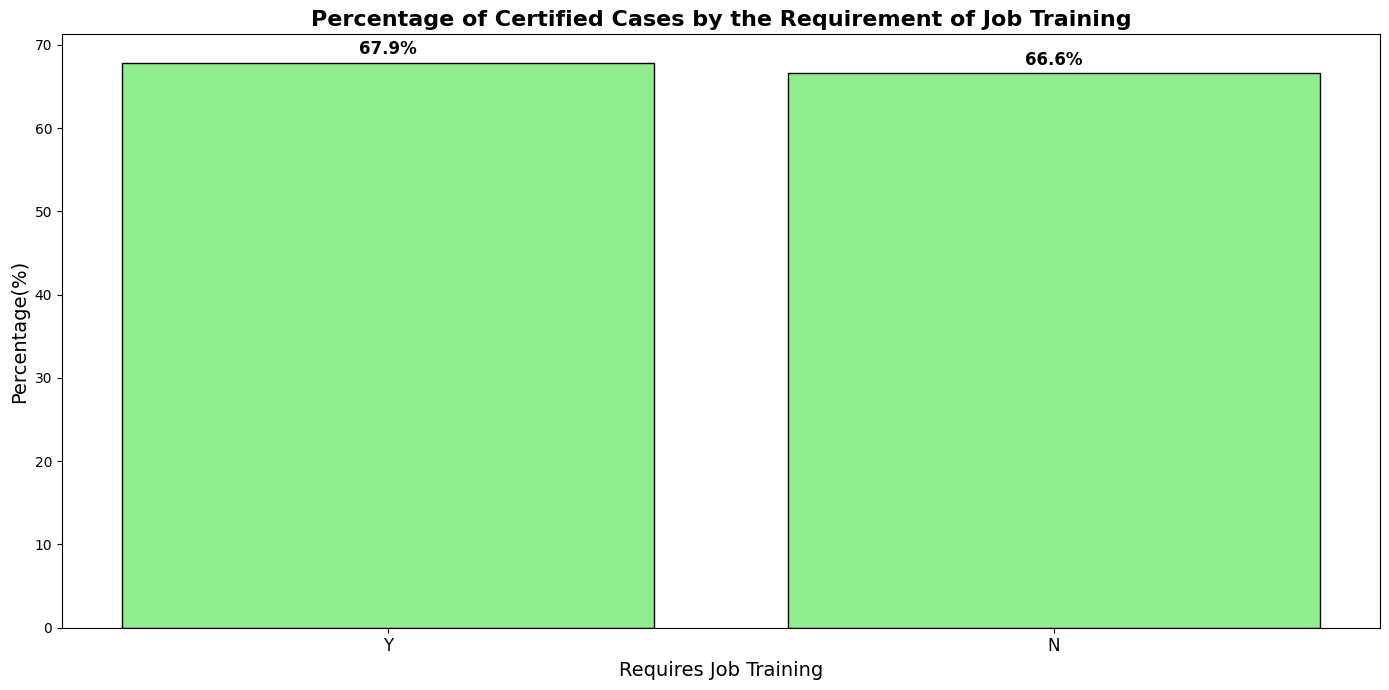

In [29]:
pct_df = pd.crosstab(df['requires_job_training'], df['case_status'], normalize='index') * 100
cert_pct = pct_df['Certified'].sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(14, 7))

bars = ax.bar(cert_pct.index, cert_pct.values, color='lightgreen', edgecolor='black')
ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=12, fontweight='bold')

ax.set_title("Percentage of Certified Cases by the Requirement of Job Training", fontsize=16, fontweight='bold')
ax.set_xlabel('Requires Job Training', fontsize=14)
ax.set_ylabel('Percentage(%)', fontsize=14)
ax.tick_params(axis='x', rotation=0, labelsize=12)
fig.tight_layout()
plt.show()

## Wages and its impact on Visa status

In [30]:
(df.groupby('unit_of_wage')['case_status'].value_counts(normalize=True).to_frame(name='percentage(%)')*100).round(2)

percentage(%)
unit_of_wage case_status               
Hour         Denied               65.37
             Certified            34.63
Month        Certified            61.80
             Denied               38.20
Week         Certified            62.13
             Denied               37.87
Year         Certified            69.89
             Denied               30.11

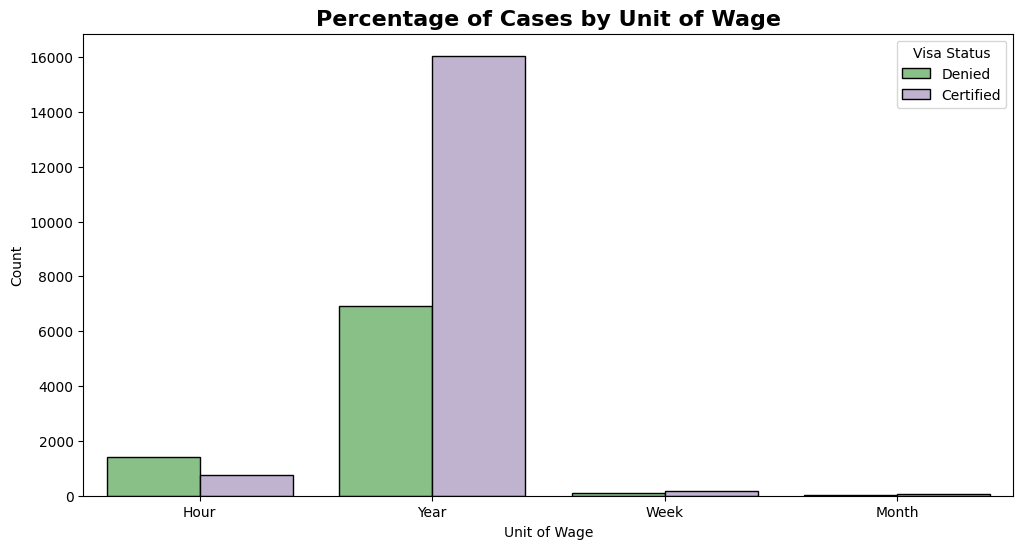

In [31]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='unit_of_wage', hue='case_status', palette='Accent', edgecolor='black')
plt.title('Percentage of Cases by Unit of Wage', fontsize=16, fontweight='bold')
plt.xlabel('Unit of Wage')
plt.ylabel('Count')
plt.legend(title='Visa Status', fancybox=True)
plt.show()

If we want to see only the `certified` cases by unit of wage, we can do the following process.

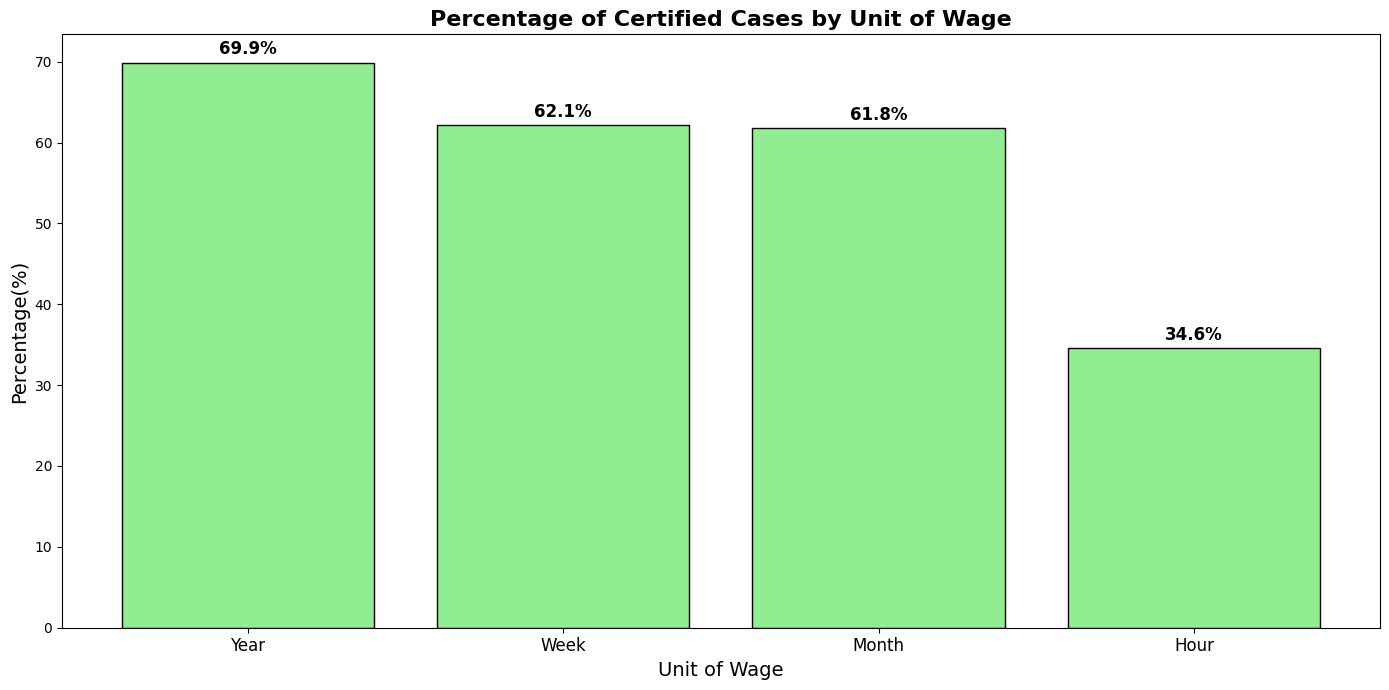

In [32]:
pct_df = pd.crosstab(df['unit_of_wage'], df['case_status'], normalize='index') * 100
cert_pct = pct_df['Certified'].sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(14, 7))

bars = ax.bar(cert_pct.index, cert_pct.values, color='lightgreen', edgecolor='black')
ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=12, fontweight='bold')

ax.set_title("Percentage of Certified Cases by Unit of Wage", fontsize=16, fontweight='bold')
ax.set_xlabel('Unit of Wage', fontsize=14)
ax.set_ylabel('Percentage(%)', fontsize=14)
ax.tick_params(axis='x', rotation=0, labelsize=12)
fig.tight_layout()
plt.show()

If we want to see how many duplicate values are there in the dataset, we can use the `duplicated()` method.

In [33]:
df.duplicated().sum()

np.int64(0)

There is no duplicate value in the dataset.

## For Feature Engineering: 
we need to focus on the following points

1. Missing value - No
2. Categorical handler - Yes
3. Outlier - Yes
4. Imbalance - Yes
5. Duplicate - No
7. Drop any column - Yes
8. Scaling - Yes
9. Transformation - Yes